Ensemble learning is a technique in machine learning where multiple models are combined to enhance overall predictive performance and robustness. Traditionally, ensembles focused on aggregating weak learners to improve accuracy; however, modern approaches demonstrate that combining multiple strong models can also lead to superior results by leveraging their complementary strengths.

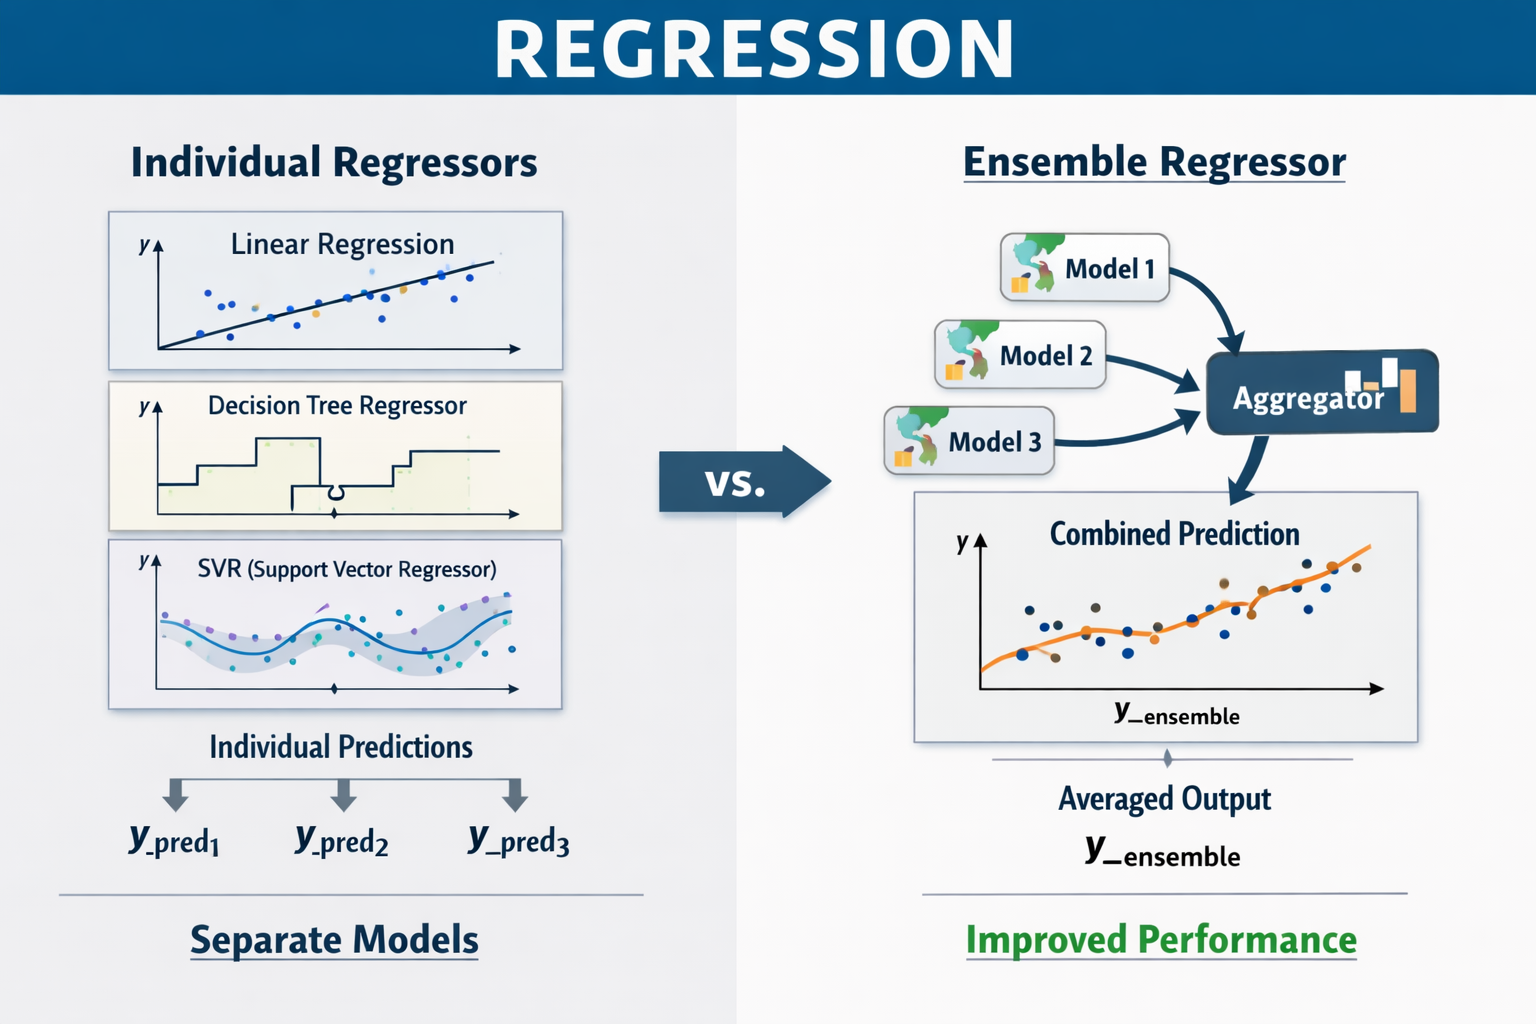

In regression tasks, ensemble techniques such as Random Forest and Voting Regressor aggregate predictions from multiple base models, typically through averaging, to enhance stability and predictive accuracy. This approach helps reduce variance and improves generalization compared to individual regressors. In this implementation, an ensemble regressor is constructed using multiple base models, and its performance is systematically compared against each standalone model to evaluate the benefits of aggregation.

Data Description & Task (Regression)

The California Housing dataset, obtained from scikit-learn, contains demographic and geographic information about housing districts in California. The target variable is MedHouseVal, which represents the median house value (scaled in units of 100,000 USD). The objective of this project is to develop regression models that can accurately predict median house values based on these input features. Three models are implemented: Linear Regression, Decision Tree Regressor, and Random Forest Regressor. These models are then combined using a Voting Regressor to form an ensemble. The workflow includes exploratory data analysis, training individual models, constructing the ensemble model, and evaluating performance using RMSE and R² metrics.

Conclusion (Regression)

The comparative analysis shows that each model exhibits distinct characteristics. Linear Regression provides a stable and interpretable baseline with moderate error and reasonable explanatory power. Decision Tree Regressor tends to achieve very low training error but often suffers from overfitting, resulting in weaker generalization on test data. Random Forest Regressor demonstrates strong performance by reducing variance and improving generalization through ensemble averaging. The Voting Regressor, which combines all three models, typically achieves performance comparable to or slightly better than the best individual model, offering improved robustness across different data patterns.

Imports

The implementation utilizes essential libraries for data processing, visualization, and modeling. NumPy and pandas are used for numerical computations and structured data handling, while matplotlib and seaborn support data visualization and exploratory analysis. The dataset is loaded using fetch_california_housing, and train_test_split is applied to divide the data into training and testing sets. Model evaluation is performed using RMSE (via mean_squared_error) and R² (via r2_score). The regression models include Linear Regression for baseline performance, Decision Tree Regressor for flexible modeling, and Random Forest Regressor for improved generalization. Finally, a Voting Regressor is implemented to aggregate predictions from multiple models, enhancing overall predictive stability.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.tree import DecisionTreeRegressor

In [2]:
#Load Data
california = fetch_california_housing(as_frame=True)
data_reg = california.frame

data_reg.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
data_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Data Analysis
The dataset is initially explored by plotting histograms for each feature in the California Housing dataset to analyze their distributional properties. This visualization helps identify key characteristics such as skewness, presence of outliers, and overall data spread, which are important for guiding preprocessing steps like scaling or transformation. The use of appropriate figure sizing and layout adjustments ensures clear and organized visualization of all features. This exploratory step provides critical insight into the underlying data structure prior to model development.

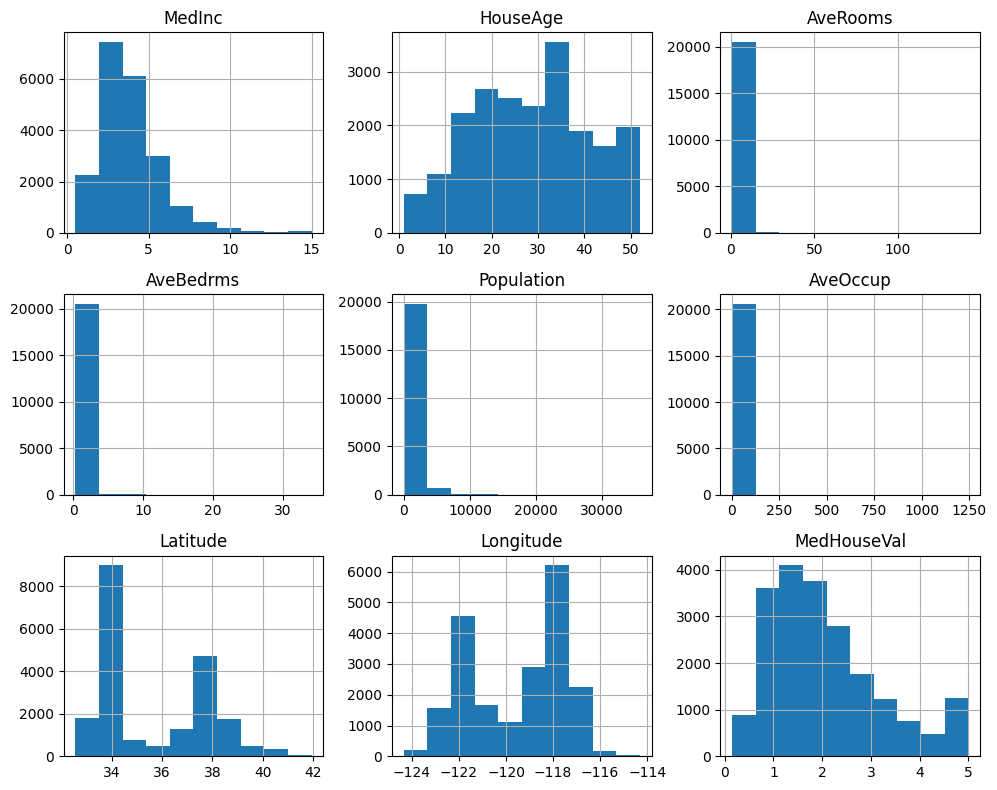

In [4]:
data_reg.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

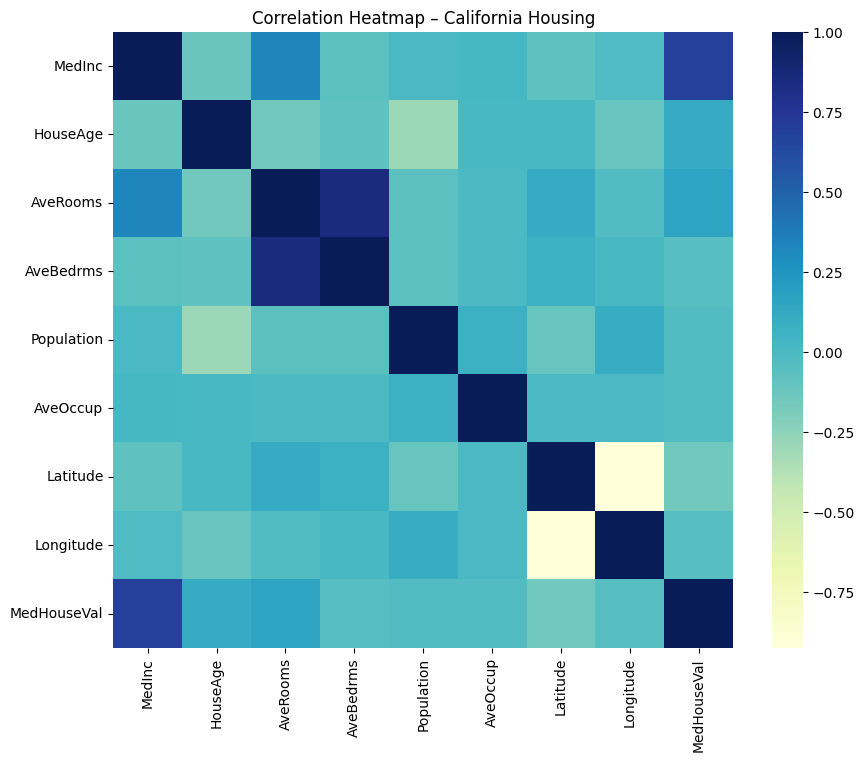

In [6]:
# Heat Map
plt.figure(figsize=(10, 8))
sns.heatmap(data_reg.corr(), annot=False, cmap='YlGnBu')
plt.title("Correlation Heatmap – California Housing")
plt.show()

Feature - Target Split and Train - Test Split

The dataset is partitioned into input features (X) and the target variable (y), where all predictor variables excluding MedHouseVal are assigned to X, and the target variable representing median house value is assigned to y. Verifying the dimensions of X and y ensures that the number of samples and features are correctly defined, confirming that the dataset is properly structured for subsequent model training and evaluation.

The dataset is partitioned into training and testing subsets using a 70/30 split, where X_train and y_train are utilized for model training, and X_test and y_test are reserved for evaluating performance on unseen data. A fixed random_state = 42 is applied to ensure reproducibility, enabling consistent and reliable comparison of model results across multiple runs.

In [7]:
X = data_reg.drop(columns=["MedHouseVal"])
y = data_reg["MedHouseVal"]

print(X.shape, y.shape)


(20640, 8) (20640,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [10]:
#Train base model
lin_reg = LinearRegression()
rf_reg = RandomForestRegressor(random_state=42)
dt_reg = DecisionTreeRegressor(random_state=42)

lin_reg.fit(X_train, y_train)
rf_reg.fit(X_train, y_train)
dt_reg.fit(X_train, y_train)


DecisionTreeRegressor(random_state=42)

In [11]:
# Evaluation Helper: This function evaluates any regression model by comparing its predictions on both the training and testing sets.

def eval_regressor(name, model, X_train, y_train, X_test, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    print(f"{name}")
    print(f" Train  - RMSE: {rmse_train:.3f}, R²: {r2_train:.3f}")
    print(f" Test   - RMSE: {rmse_test:.3f}, R²: {r2_test:.3f}")
    print("-" * 40)

In [12]:
#Evaluate Base Model
eval_regressor("LinearRegression", lin_reg, X_train, y_train, X_test, y_test)
eval_regressor("RandomForestRegressor", rf_reg, X_train, y_train, X_test, y_test)
eval_regressor("DecisionTreeRegressor", dt_reg, X_train, y_train, X_test, y_test)


LinearRegression
 Train  - RMSE: 0.723, R²: 0.609
 Test   - RMSE: 0.728, R²: 0.596
----------------------------------------
RandomForestRegressor
 Train  - RMSE: 0.192, R²: 0.972
 Test   - RMSE: 0.506, R²: 0.805
----------------------------------------
DecisionTreeRegressor
 Train  - RMSE: 0.000, R²: 1.000
 Test   - RMSE: 0.727, R²: 0.598
----------------------------------------


In [14]:
#Voting Regressor: A VotingRegressor is created by combining three models: Linear Regression, Random Forest Regressor, and Decision Tree Regressor.
voting_reg = VotingRegressor(
    estimators=[
        ('lr', lin_reg),
        ('rf', rf_reg),
        ('dt', dt_reg)
    ]
)

voting_reg.fit(X_train, y_train)
eval_regressor("VotingRegressor", voting_reg, X_train, y_train, X_test, y_test)



VotingRegressor
 Train  - RMSE: 0.290, R²: 0.937
 Test   - RMSE: 0.559, R²: 0.762
----------------------------------------


The residuals, defined as the difference between actual and predicted median house values, are computed to analyze model error. A scatter plot of residuals versus predicted values is used to assess error patterns and model behavior. Ideally, residuals should be randomly distributed around the zero line, indicating unbiased predictions with no systematic trends. A horizontal reference line at zero highlights overestimation and underestimation regions. This visualization provides insight into the stability and generalization capability of the Voting Regressor, helping identify whether prediction errors remain consistent or vary across different value ranges.

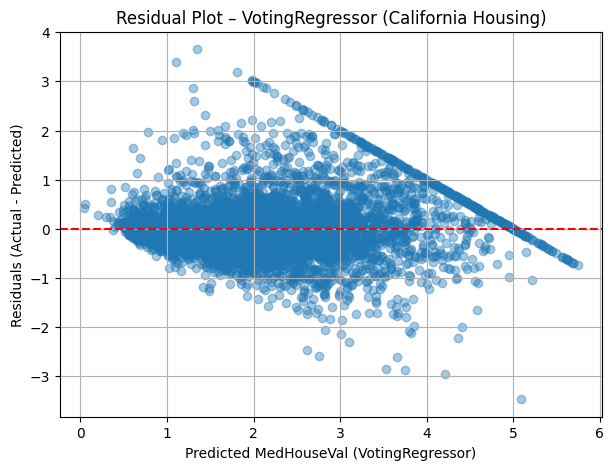

In [15]:
y_pred_voting = voting_reg.predict(X_test)
residuals = y_test - y_pred_voting

plt.figure(figsize=(7, 5))
plt.scatter(y_pred_voting, residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted MedHouseVal (VotingRegressor)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot – VotingRegressor (California Housing)")
plt.grid(True)
plt.show()

Model Comparison – Linear Regression, Random Forest, Decision Tree, and Voting Regressor

Linear Regression demonstrates moderate and consistent performance, with comparable RMSE and R² values across both training and testing sets, indicating stable behavior but limited capability in capturing nonlinear relationships. The Random Forest Regressor achieves near-perfect performance on the training data, reflected by very low RMSE and high R², suggesting strong model capacity; however, the increase in test error indicates slight overfitting, though it still generalizes significantly better than the other individual models. In contrast, the Decision Tree Regressor attains perfect training performance (RMSE = 0, R² = 1.0), clearly indicating overfitting, as its test performance aligns closely with Linear Regression, reflecting poor generalization.

The Voting Regressor, which integrates predictions from Linear Regression, Random Forest, and Decision Tree models, achieves a well-balanced performance. With a high training R²(0.937) that avoids overfitting and a strong test R² (~0.762), it delivers competitive results close to the best-performing individual model. Furthermore, the residual analysis reveals that errors are randomly distributed around zero without noticeable patterns, indicating unbiased predictions and strong model stability across different value ranges.

Final Conclusion

Among the individual models, the Random Forest Regressor achieves the strongest performance on the test set, although it exhibits mild overfitting due to its high training accuracy. The Decision Tree Regressor significantly overfits the training data and fails to generalize effectively to unseen samples. Linear Regression, while stable and consistent across training and testing, shows limited predictive capability due to its inability to capture complex nonlinear relationships. The Voting Regressor, which combines all three models, provides the most balanced performance by effectively managing the bias–variance trade-off. Its residual distribution indicates reduced systematic error and improved prediction stability. Overall, the Voting Regressor stands out as a robust and reliable model, delivering strong predictive accuracy without severe overfitting for this regression task.